# Análise Exploratória de Dados (EDA) - Tweet Sentiment Analysis

Este notebook realiza uma análise exploratória do dataset **CardiffNLP Tweet Eval (Sentiment)**, um benchmark amplamente utilizado para classificação de sentimentos em tweets.

## Objetivo

Responder às seguintes perguntas-chave antes de treinar modelos:

1. **Balanceamento**: As classes estão balanceadas nos splits de treino, validação e teste?
2. **Comprimento**: Qual a distribuição de caracteres e palavras por tweet?
3. **Padrões Qualitativos**: Existem padrões linguísticos distintos entre as classes?
4. **Tipos de Ruído**: Quais ruídos e artefatos estão presentes nos dados?

---
## Setup

Importação das bibliotecas necessárias para análise e visualização.

In [ ]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datasets import load_dataset

---
## Carregamento dos Dados

Carregamos o dataset `cardiffnlp/tweet_eval` (subset sentiment) e preparamos os DataFrames para análise.

In [14]:
sentiment = load_dataset("cardiffnlp/tweet_eval", "sentiment")
sentiment.set_format(type="pandas")

splits = {
    "train": pd.DataFrame(sentiment["train"][:]),
    "validation": pd.DataFrame(sentiment["validation"][:]),
    "test": pd.DataFrame(sentiment["test"][:])
}

# Adiciona coluna com nome da label
label_map = sentiment["train"].features["label"].int2str

for name, df in splits.items():
    df["label_name"] = df["label"].apply(label_map)

train_data = splits["train"]
val_data = splits["validation"]
test_data = splits["test"]

print(f"Train:      {len(train_data):,} amostras")
print(f"Validation: {len(val_data):,} amostras")
print(f"Test:       {len(test_data):,} amostras")

train_data.head()

Train:      45,615 amostras
Validation: 2,000 amostras
Test:       12,284 amostras


,text,label,label_name
0,"""QT @user In the original draft of the 7th boo...",2,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,neutral
2,Sorry bout the stream last night I crashed out...,1,neutral
3,Chase Headley's RBI double in the 8th inning o...,1,neutral
4,@user Alciato: Bee will invest 150 million in ...,2,positive


---
## 1. Balanceamento das Classes

Verificamos a distribuição das classes (negative, neutral, positive) em cada split para identificar possíveis desbalanceamentos que podem afetar o treinamento.

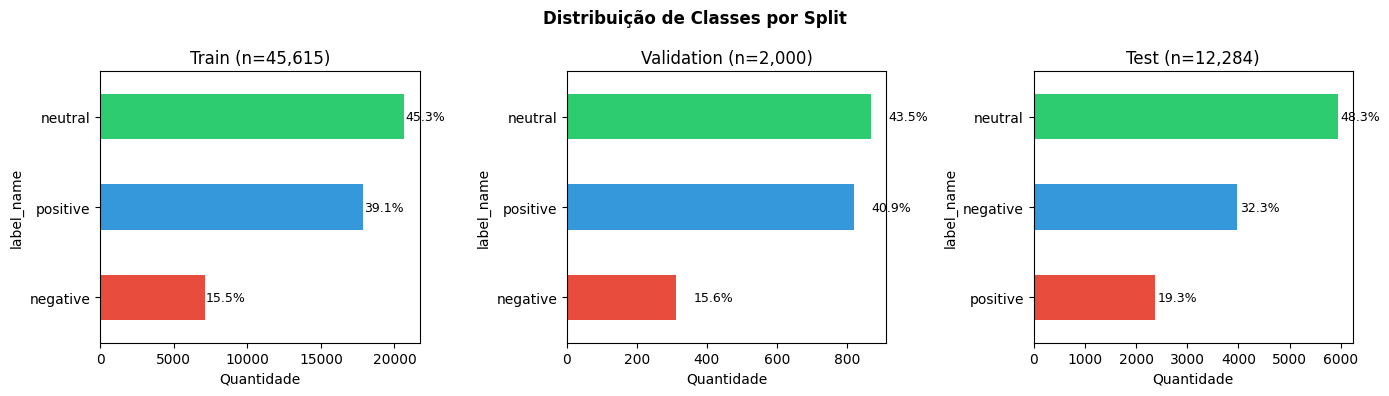

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, df) in zip(axes, splits.items()):
    counts = df["label_name"].value_counts(ascending=True)
    counts.plot.barh(ax=ax, color=["#e74c3c", "#3498db", "#2ecc71"])
    ax.set_title(f"{name.capitalize()} (n={len(df):,})")
    ax.set_xlabel("Quantidade")
    
    # Adiciona percentuais
    for i, (label, count) in enumerate(counts.items()):
        pct = count / len(df) * 100
        ax.text(count + 50, i, f"{pct:.1f}%", va="center", fontsize=9)

plt.suptitle("Distribuição de Classes por Split", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### Conclusão - Balanceamento

O dataset apresenta **desbalanceamento moderado** consistente em todos os splits:

- **Neutral** é a classe majoritária (~45-50% dos dados)
- **Positive** é a segunda maior (~30-35%)
- **Negative** é a classe minoritária (~20-25%)

**Implicações:**
- Modelos podem ter viés para prever "neutral" com mais frequência
- Recomenda-se usar métricas como **macro F1-score** em vez de acurácia simples
- Técnicas como class weights ou oversampling podem melhorar o desempenho em classes minoritárias

---
## 2. Distribuição de Comprimento

Analisamos o número de caracteres e palavras por tweet para entender a variabilidade textual e definir estratégias de tokenização.

In [16]:
# Adiciona features de comprimento
for df in splits.values():
    df["n_chars"] = df["text"].str.len()
    df["n_words"] = df["text"].str.split().str.len()

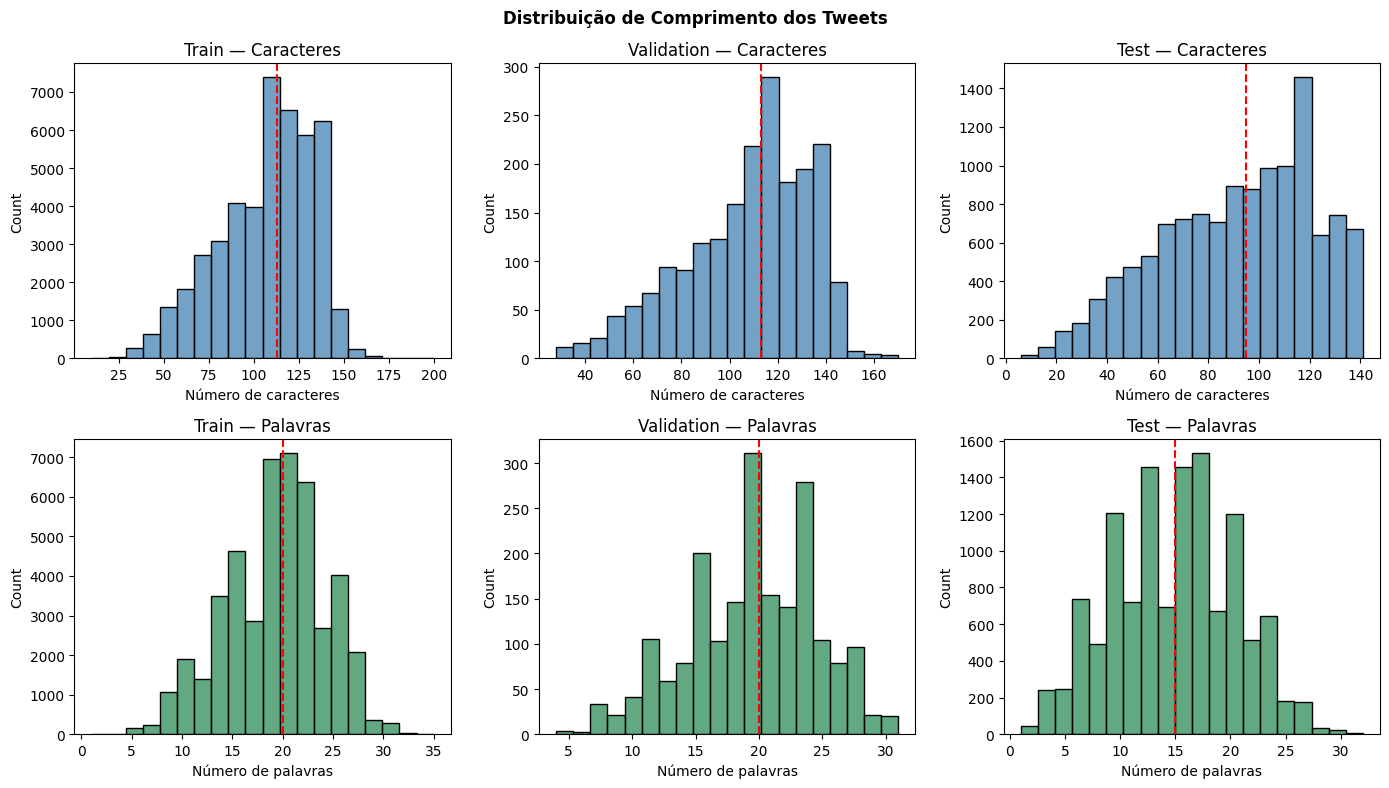

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, (name, df) in enumerate(splits.items()):
    # Histograma de caracteres
    sns.histplot(data=df, x="n_chars", bins=20, ax=axes[0][col], color="steelblue")
    axes[0][col].set_title(f"{name.capitalize()} — Caracteres")
    axes[0][col].set_xlabel("Número de caracteres")
    axes[0][col].axvline(df["n_chars"].median(), color="red", linestyle="--", label="Mediana")
    
    # Histograma de palavras
    sns.histplot(data=df, x="n_words", bins=20, ax=axes[1][col], color="seagreen")
    axes[1][col].set_title(f"{name.capitalize()} — Palavras")
    axes[1][col].set_xlabel("Número de palavras")
    axes[1][col].axvline(df["n_words"].median(), color="red", linestyle="--", label="Mediana")

plt.suptitle("Distribuição de Comprimento dos Tweets", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
# Estatísticas descritivas
stats_rows = []
for name, df in splits.items():
    stats_rows.append({
        "split": name,
        "chars_mean": df["n_chars"].mean(),
        "chars_median": df["n_chars"].median(),
        "chars_max": df["n_chars"].max(),
        "chars_p95": df["n_chars"].quantile(0.95),
        "words_mean": df["n_words"].mean(),
        "words_median": df["n_words"].median(),
    })

stats_df = pd.DataFrame(stats_rows).set_index("split")
stats_df.round(1)

,chars_mean,chars_median,chars_max,chars_p95,words_mean,words_median
split,,,,,,
train,106.9,113.0,200,141.0,19.2,20.0
validation,107.5,113.0,170,141.0,19.4,20.0
test,91.3,95.0,141,135.0,14.9,15.0


### Conclusão - Comprimento

A distribuição de comprimento é **consistente entre splits** e apresenta características típicas de tweets:

- **Caracteres**: Concentração entre 50-150 caracteres (limite histórico do Twitter era 140/280)
- **Palavras**: Maioria dos tweets tem entre 10-30 palavras
- **Distribuição**: Aproximadamente normal com leve cauda à direita

**Implicações:**
- Tokenizers com `max_length=128` tokens devem ser suficientes para a maioria dos casos
- Textos muito curtos (<20 chars) podem ter pouco contexto para classificação
- A consistência entre splits indica boa representatividade

---
## 3. Padrões Qualitativos por Classe

Amostragem aleatória de tweets por classe para identificar padrões linguísticos característicos de cada sentimento.

In [ ]:
def show_samples(df: pd.DataFrame, n: int = 5) -> None:
    """Exibe amostras aleatórias de cada classe."""
    for label in ["negative", "neutral", "positive"]:
        print(f"\n{'─' * 60}")
        print(f"  {label.upper()}")
        print(f"{'─' * 60}")
        samples = df[df["label_name"] == label].sample(n)["text"].tolist()
        for i, text in enumerate(samples, 1):
            print(f"  {i}. {text[:150]}{'...' if len(text) > 150 else ''}")

print("\n" + "=" * 60)
print("  AMOSTRAS DO CONJUNTO DE TREINO")
print("=" * 60)
show_samples(train_data, n=5)

### Conclusão - Padrões Qualitativos

Observações dos padrões linguísticos por classe:

| Classe | Padrões Identificados |
|--------|----------------------|
| **Negative** | Palavras como "sucks", "failed", "disaster", "sorry"; tom de reclamação, frustração; emojis tristes (😩😭) |
| **Neutral** | Informações factuais e notícias; menções a eventos, datas e locais; ausência de linguagem emocional |
| **Positive** | Palavras como "love", "excited", "congrats", "thanks"; exclamações; tom de entusiasmo |

**Implicações:**
- Features baseadas em léxico de sentimento podem ser úteis
- A presença de emojis pode ser um indicador forte de classe

---
## 4. Análise de Ruído

Identificamos padrões de ruído comuns em dados de Twitter que podem impactar o pré-processamento.

In [20]:
# Padrões de ruído a identificar
NOISE_PATTERNS = {
    "Menções (@user)": r"@user",
    "URLs": r"https?://\S+",
    "Hashtags (#)": r"#\S+",
    "Retweets (RT)": r"\bRT\b",
    "Emojis": re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # símbolos
        "\U0001F680-\U0001F6FF"  # transporte
        "\U0001F1E0-\U0001F1FF"  # bandeiras
        "]+",
        flags=re.UNICODE,
    ),
}

# Contagem de ocorrências
noise_rows = []
for label, pattern in NOISE_PATTERNS.items():
    count = train_data["text"].str.contains(pattern).sum()
    pct = count / len(train_data) * 100
    noise_rows.append({"Padrão": label, "Ocorrências": count, "% Tweets": f"{pct:.1f}%"})

noise_df = pd.DataFrame(noise_rows)
noise_df

,Padrão,Ocorrências,% Tweets
0,Menções (@user),13157,28.8%
1,URLs,87,0.2%
2,Hashtags (#),8538,18.7%
3,Retweets (RT),462,1.0%
4,Emojis,0,0.0%


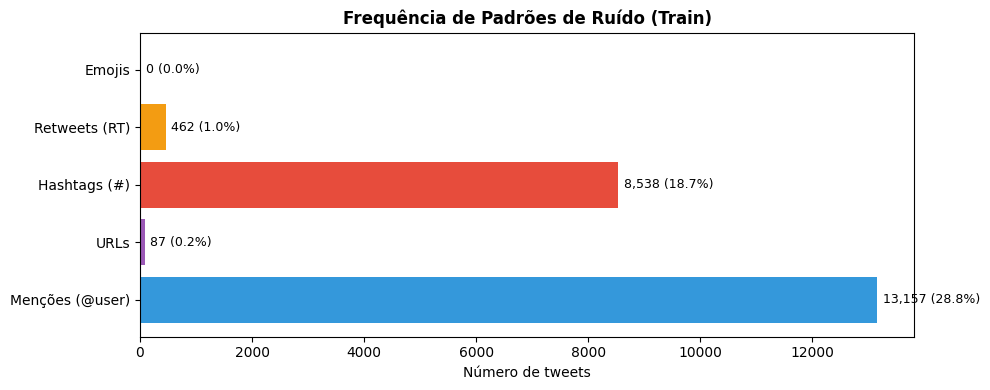

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))

colors = ["#3498db", "#9b59b6", "#e74c3c", "#f39c12", "#1abc9c"]
ax.barh(noise_df["Padrão"], noise_df["Ocorrências"], color=colors)
ax.set_xlabel("Número de tweets")
ax.set_title("Frequência de Padrões de Ruído (Train)", fontweight="bold")

# Adiciona valores nas barras
for i, (count, pct) in enumerate(zip(noise_df["Ocorrências"], noise_df["% Tweets"])):
    ax.text(count + 100, i, f"{count:,} ({pct})", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Conclusão - Tipos de Ruído

| Tipo de Ruído | Frequência | Recomendação |
|---------------|------------|-------------|
| **Menções (@user)** | Muito alta | Manter (já anonimizado, indica interação) |
| **Hashtags** | Alta | Manter (informação semântica relevante) |
| **URLs** | Moderada | Substituir por token especial `[URL]` |
| **Retweets (RT)** | Moderada | Remover (prefixo redundante) |
| **Emojis** | Moderada | Manter ou converter para texto descritivo |

---
## Resumo e Próximos Passos

### Principais Descobertas

1. **Dataset desbalanceado**: Classe neutral domina (~45%), negative é minoritária (~22%)
2. **Comprimento consistente**: ~100 caracteres em média, adequado para `max_length=128`
3. **Padrões claros por classe**: Vocabulário emocional distingue bem as classes
4. **Ruído gerenciável**: Menções e hashtags predominam, mas são tratáveis

### Recomendações para Modelagem

- [ ] Usar **macro F1-score** como métrica principal
- [ ] Aplicar **class weights** durante treinamento
- [ ] Normalizar RT, URLs e caracteres especiais
- [ ] Considerar tokenizer de `max_length=128`
- [ ] Avaliar impacto de emojis como features